In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


SEPARAR DATASET EN ACTIVOS / ELIMINADOS

In [ ]:
# Importando la biblioteca pandas para manipulación y análisis de datos
import pandas as pd
business_payments = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/merged_inner.csv')

In [ ]:
business_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21057 entries, 0 to 21056
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          21057 non-null  int64  
 1   cash_request_id             21057 non-null  int64  
 2   type                        21057 non-null  object 
 3   status                      21057 non-null  object 
 4   category                    2196 non-null   object 
 5   total_amount                21057 non-null  float64
 6   reason                      21057 non-null  object 
 7   created_at                  21057 non-null  object 
 8   updated_at                  21057 non-null  object 
 9   paid_at                     15438 non-null  object 
 10  from_date                   6749 non-null   object 
 11  to_date                     6512 non-null   object 
 12  charge_moment               21057 non-null  object 
 13  amount                      210

In [ ]:
import pandas as pd

# Cargar el archivo CSV original
file_path = 'drive/MyDrive/ColabNotebooks/Business_Payments/merged_inner.csv'  # Cambia esta ruta según corresponda
data = pd.read_csv(file_path)

# Separar los datos en usuarios activos y eliminados
usuarios_activos = data[data['user_id'].notna()]
usuarios_eliminados = data[data['deleted_account_id'].notna()]

# Guardar los datos en archivos CSV separados
usuarios_activos.to_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos.csv', index=False)
usuarios_eliminados.to_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados.csv.csv', index=False)

print("Archivos generados: 'usuarios_activos.csv' y 'usuarios_eliminados.csv'")


Archivos generados: 'usuarios_activos.csv' y 'usuarios_eliminados.csv'


--------------------------------------------------------------------------------------------------------

LIMPIEZA COLUMNAS Y CONVERSIÓN FECHAS
```



In [3]:
import pandas as pd

In [4]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados.csv.csv')

In [5]:
# Eliminar columnas no necesarias
usuarios_activos = usuarios_activos.drop(columns=['deleted_account_id'], errors='ignore')
usuarios_eliminados = usuarios_eliminados.drop(columns=['user_id'], errors='ignore')

In [6]:
import pandas as pd
import pytz

# Definir la zona horaria deseada (puedes cambiar 'UTC' por otra como 'America/New_York')
desired_timezone = pytz.UTC

# Convertir columnas de fechas a datetime y ajustar al mismo timezone
date_columns = [
    'created_at', 'updated_at', 'paid_at', 'from_date', 'to_date',
    'cash_request_created_at', 'cash_request_updated_at', 'moderated_at',
    'reimbursement_date', 'cash_request_received_date', 'money_back_date',
    'send_at', 'reco_creation', 'reco_last_update'
]

for col in date_columns:
    if col in usuarios_activos.columns:
        # Convertir a datetime y manejar errores
        usuarios_activos[col] = pd.to_datetime(usuarios_activos[col], errors='coerce')

        # Ajustar al timezone deseado
        usuarios_activos[col] = usuarios_activos[col].apply(
            lambda x: x.tz_convert(desired_timezone) if pd.notnull(x) and x.tzinfo else (
                x.tz_localize('UTC').tz_convert(desired_timezone) if pd.notnull(x) else x
            )
        )

# Convertir identificadores a int (si no tienen valores faltantes)
id_columns = ['id', 'cash_request_id', 'user_id']

for col in id_columns:
    if col in usuarios_activos.columns:
        # Verificar si la columna contiene valores faltantes
        if usuarios_activos[col].isnull().any():
            print(f"La columna {col} tiene valores faltantes, no se convertirá a int.")
        else:
            usuarios_activos[col] = usuarios_activos[col].astype(int)

# Confirmar las conversiones
print(usuarios_activos.dtypes)



id                                          int64
cash_request_id                             int64
type                                       object
status                                     object
category                                   object
total_amount                              float64
reason                                     object
created_at                    datetime64[ns, UTC]
updated_at                    datetime64[ns, UTC]
paid_at                       datetime64[ns, UTC]
from_date                     datetime64[ns, UTC]
to_date                       datetime64[ns, UTC]
charge_moment                              object
amount                                    float64
cash_request_status                        object
cash_request_created_at       datetime64[ns, UTC]
cash_request_updated_at       datetime64[ns, UTC]
user_id                                     int64
moderated_at                  datetime64[ns, UTC]
reimbursement_date            datetime64[ns, UTC]


In [7]:
import pandas as pd
import pytz

# Definir la zona horaria deseada (puedes cambiar 'UTC' por otra como 'America/New_York')
desired_timezone = pytz.UTC

# Convertir columnas de fechas a datetime y ajustar al mismo timezone
date_columns = [
    'created_at', 'updated_at', 'paid_at', 'from_date', 'to_date',
    'cash_request_created_at', 'cash_request_updated_at', 'moderated_at',
    'reimbursement_date', 'cash_request_received_date', 'money_back_date',
    'send_at', 'reco_creation', 'reco_last_update'
]

for col in date_columns:
    if col in usuarios_eliminados.columns:
        # Convertir a datetime y manejar errores
        usuarios_eliminados[col] = pd.to_datetime(usuarios_eliminados[col], errors='coerce')

        # Ajustar al timezone deseado
        usuarios_eliminados[col] = usuarios_eliminados[col].apply(
            lambda x: x.tz_convert(desired_timezone) if pd.notnull(x) and x.tzinfo else (
                x.tz_localize('UTC').tz_convert(desired_timezone) if pd.notnull(x) else x
            )
        )

# Convertir identificadores a int (si no tienen valores faltantes)
id_columns = ['id', 'cash_request_id', 'deleted_account_id']

for col in id_columns:
    if col in usuarios_eliminados.columns:
        # Verificar si la columna contiene valores faltantes
        if usuarios_eliminados[col].isnull().any():
            print(f"La columna {col} tiene valores faltantes, no se convertirá a int.")
        else:
            usuarios_eliminados[col] = usuarios_eliminados[col].astype(int)

# Confirmar las conversiones
print(usuarios_eliminados.dtypes)


id                                          int64
cash_request_id                             int64
type                                       object
status                                     object
category                                   object
total_amount                              float64
reason                                     object
created_at                    datetime64[ns, UTC]
updated_at                    datetime64[ns, UTC]
paid_at                       datetime64[ns, UTC]
from_date                     datetime64[ns, UTC]
to_date                       datetime64[ns, UTC]
charge_moment                              object
amount                                    float64
cash_request_status                        object
cash_request_created_at       datetime64[ns, UTC]
cash_request_updated_at       datetime64[ns, UTC]
moderated_at                  datetime64[ns, UTC]
deleted_account_id                          int64
reimbursement_date            datetime64[ns, UTC]


RELLENAR VALORES NUMERICOS CON LA MEDIA

In [8]:
# Función para clasificar usuarios en categorías según montos solicitados
def clasificar_usuario(row, thresholds):
    if row['total_amount_requested'] > thresholds['gold']:
        return 'Gold'
    elif row['total_amount_requested'] > thresholds['silver']:
        return 'Silver'
    else:
        return 'Bronze'

# Definir umbrales basados en percentiles
thresholds_activos = {
    'gold': 250,  # >75% para usuarios activos
    'silver': 100  # Mediana a 75% para usuarios activos
}

thresholds_eliminados = {
    'gold': 300,  # >75% para usuarios eliminados
    'silver': 150  # Mediana a 75% para usuarios eliminados
}

# Calcular métricas por usuario en usuarios activos
activos_summary = usuarios_activos.groupby('user_id').agg(
    total_amount_requested=('amount', 'sum'),
    total_transactions=('id', 'count'),
    total_repaid=('total_amount', 'sum')
).reset_index()

# Clasificar usuarios activos y agregar al dataset original
activos_summary['categoria'] = activos_summary.apply(clasificar_usuario, axis=1, thresholds=thresholds_activos)
usuarios_activos = usuarios_activos.merge(activos_summary[['user_id', 'categoria']], on='user_id', how='left')

# Calcular métricas por usuario en usuarios eliminados
eliminados_summary = usuarios_eliminados.groupby('deleted_account_id').agg(
    total_amount_requested=('amount', 'sum'),
    total_transactions=('id', 'count'),
    total_repaid=('total_amount', 'sum')
).reset_index()

# Clasificar usuarios eliminados y agregar al dataset original
eliminados_summary['categoria'] = eliminados_summary.apply(clasificar_usuario, axis=1, thresholds=thresholds_eliminados)
usuarios_eliminados = usuarios_eliminados.merge(eliminados_summary[['deleted_account_id', 'categoria']], left_on='deleted_account_id', right_on='deleted_account_id', how='left')

# Verificar las primeras filas con la nueva columna
print("Usuarios Activos con clasificación:")
print(usuarios_activos.head())

print("\nUsuarios Eliminados con clasificación:")
print(usuarios_eliminados.head())


Usuarios Activos con clasificación:
      id  cash_request_id             type    status               category  \
0   6537            14941  instant_payment  rejected                    NaN   
1   6961            11714         incident  accepted  rejected_direct_debit   
2  16296            23371  instant_payment  accepted                    NaN   
3  20775            26772  instant_payment  accepted                    NaN   
4  17029            24052  instant_payment  accepted                    NaN   

   total_amount                              reason  \
0           5.0  Instant Payment Cash Request 14941   
1           5.0               rejected direct debit   
2           5.0  Instant Payment Cash Request 23371   
3           5.0  Instant Payment Cash Request 26772   
4           5.0  Instant Payment Cash Request 24052   

                        created_at                       updated_at  \
0 2020-09-07 10:47:27.423150+00:00 2020-10-13 14:25:09.396112+00:00   
1 2020-09-09 20:

In [10]:
# Verificar si hay valores nulos en la columna 'categoria' en usuarios activos
missing_activos = usuarios_activos['categoria'].isnull().sum()
total_activos = len(usuarios_activos)

# Verificar si hay valores nulos en la columna 'categoria' en usuarios eliminados
missing_eliminados = usuarios_eliminados['categoria'].isnull().sum()
total_eliminados = len(usuarios_eliminados)

# Resumen de categorías
categorias_activos = usuarios_activos['categoria'].value_counts()
categorias_eliminados = usuarios_eliminados['categoria'].value_counts()

# Resultados
print(f"Usuarios Activos - Total: {total_activos}, Sin Categoría: {missing_activos}")
print("Distribución por Categoría - Usuarios Activos:")
print(categorias_activos)

print(f"\nUsuarios Eliminados - Total: {total_eliminados}, Sin Categoría: {missing_eliminados}")
print("Distribución por Categoría - Usuarios Eliminados:")
print(categorias_eliminados)


Usuarios Activos - Total: 20151, Sin Categoría: 0
Distribución por Categoría - Usuarios Activos:
categoria
Gold      10107
Bronze     5600
Silver     4444
Name: count, dtype: int64

Usuarios Eliminados - Total: 906, Sin Categoría: 0
Distribución por Categoría - Usuarios Eliminados:
categoria
Gold      452
Bronze    228
Silver    226
Name: count, dtype: int64


In [11]:
# Convertir las fechas a formato datetime
usuarios_activos['created_at'] = pd.to_datetime(usuarios_activos['created_at'], errors='coerce')
usuarios_eliminados['created_at'] = pd.to_datetime(usuarios_eliminados['created_at'], errors='coerce')

# Crear columna 'Mes' indicando el mes de cada solicitud
usuarios_activos['Mes'] = usuarios_activos['created_at'].dt.to_period('M')
usuarios_eliminados['Mes'] = usuarios_eliminados['created_at'].dt.to_period('M')

# Verificar las primeras filas con la nueva columna
print("Usuarios Activos con columna 'Mes':")
print(usuarios_activos[['user_id', 'created_at', 'Mes']].head())

print("\nUsuarios Eliminados con columna 'Mes':")
print(usuarios_eliminados[['deleted_account_id', 'created_at', 'Mes']].head())


Usuarios Activos con columna 'Mes':
   user_id                       created_at      Mes
0    35661 2020-09-07 10:47:27.423150+00:00  2020-09
1    16158 2020-09-09 20:51:17.998653+00:00  2020-09
2    81575 2020-10-23 10:10:58.352972+00:00  2020-10
3    94393 2020-10-31 15:46:53.643958+00:00  2020-10
4    90386 2020-10-24 12:22:27.666102+00:00  2020-10

Usuarios Eliminados con columna 'Mes':
   deleted_account_id                       created_at      Mes
0               19005 2020-10-06 08:20:17.170432+00:00  2020-10
1               29610 2020-10-24 10:22:47.111527+00:00  2020-10
2               23059 2020-10-16 23:48:55.379796+00:00  2020-10
3               26653 2020-11-01 23:01:27.934752+00:00  2020-11
4               23893 2020-10-06 06:34:48.209743+00:00  2020-10


<ipython-input-11-82401dc97409>:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usuarios_activos['Mes'] = usuarios_activos['created_at'].dt.to_period('M')
<ipython-input-11-82401dc97409>:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usuarios_eliminados['Mes'] = usuarios_eliminados['created_at'].dt.to_period('M')


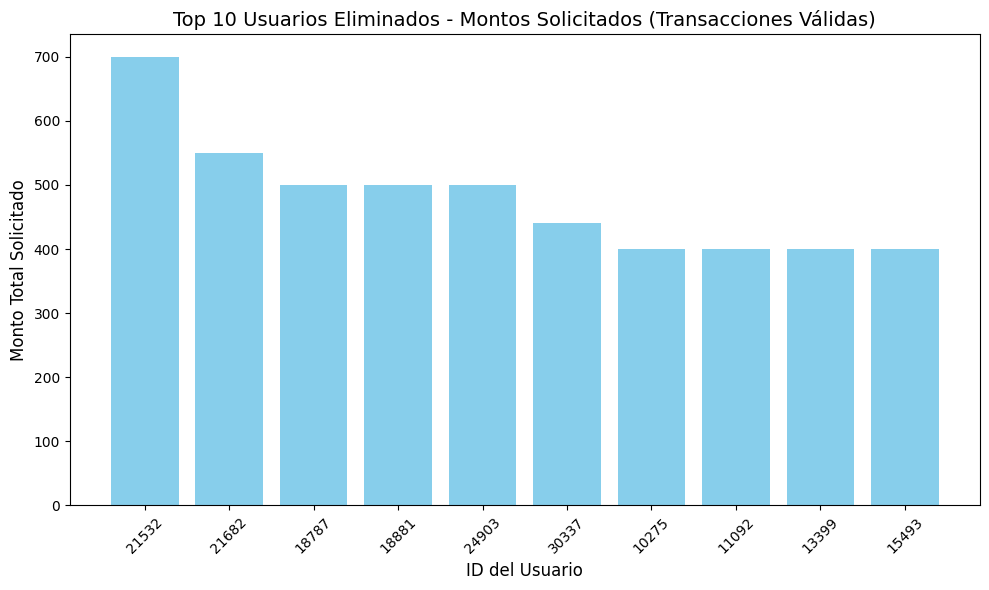

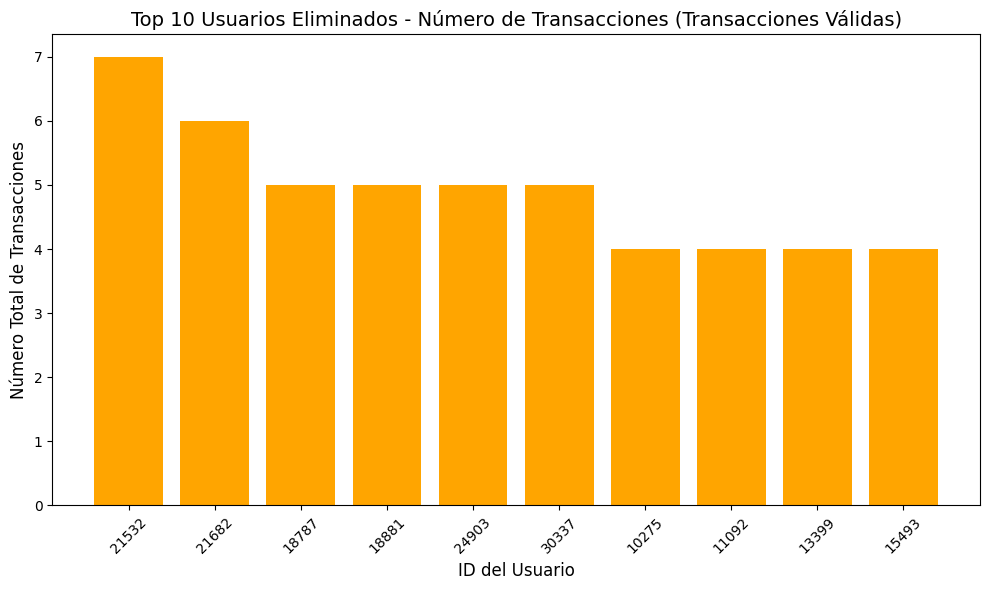

In [12]:
# Filtrar transacciones válidas: considerar estado de transacciones como 'accepted' para usuarios eliminados
valid_transactions_eliminados = usuarios_eliminados[usuarios_eliminados['status'] == 'accepted']

# Agrupar métricas por usuario en transacciones válidas para usuarios eliminados
valid_eliminados_summary = valid_transactions_eliminados.groupby('deleted_account_id').agg(
    total_amount_requested=('amount', 'sum'),
    total_transactions=('id', 'count'),
    total_repaid=('total_amount', 'sum')
).reset_index()

# Identificar el Top 10 usuarios con mayores montos solicitados en transacciones válidas (usuarios eliminados)
top_10_valid_eliminados = valid_eliminados_summary.nlargest(10, 'total_amount_requested')

# Graficar el comportamiento del Top 10 usuarios eliminados en términos de montos solicitados y transacciones válidas
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(top_10_valid_eliminados['deleted_account_id'].astype(str), top_10_valid_eliminados['total_amount_requested'], color='skyblue')
plt.title('Top 10 Usuarios Eliminados - Montos Solicitados (Transacciones Válidas)', fontsize=14)
plt.xlabel('ID del Usuario', fontsize=12)
plt.ylabel('Monto Total Solicitado', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

# Graficar número de transacciones del Top 10 usuarios eliminados
plt.figure(figsize=(10, 6))
plt.bar(top_10_valid_eliminados['deleted_account_id'].astype(str), top_10_valid_eliminados['total_transactions'], color='orange')
plt.title('Top 10 Usuarios Eliminados - Número de Transacciones (Transacciones Válidas)', fontsize=14)
plt.xlabel('ID del Usuario', fontsize=12)
plt.ylabel('Número Total de Transacciones', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()


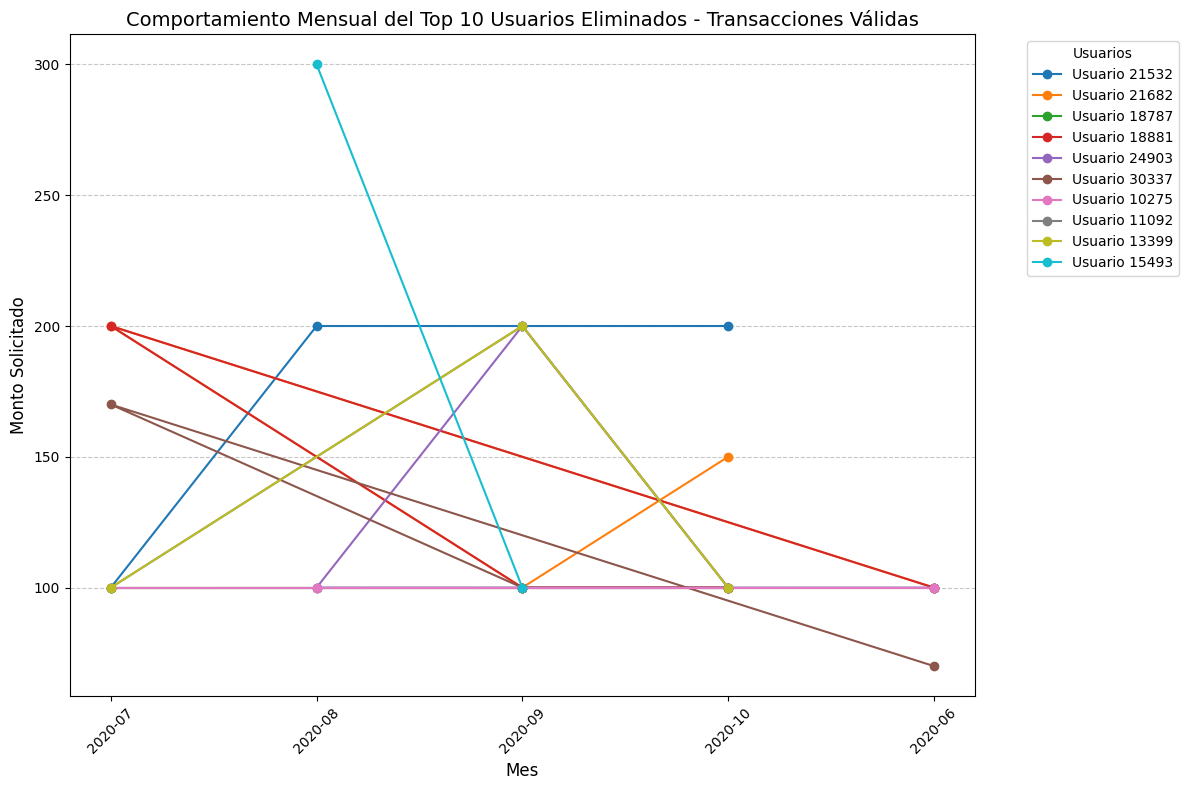

In [17]:
# Filtrar las solicitudes del Top 10 usuarios eliminados con transacciones válidas
top_10_valid_transactions = valid_transactions_eliminados[valid_transactions_eliminados['deleted_account_id'].isin(top_10_valid_eliminados['deleted_account_id'])]

# Agrupar por usuario y mes, sumando los montos solicitados
top_10_monthly = top_10_valid_transactions.groupby(['deleted_account_id', 'Mes'])['amount'].sum().reset_index()

# Crear el gráfico de líneas para el comportamiento mensual del Top 10
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for user_id in top_10_valid_eliminados['deleted_account_id']:
    user_data = top_10_monthly[top_10_monthly['deleted_account_id'] == user_id]
    plt.plot(user_data['Mes'].astype(str), user_data['amount'], marker='o', linestyle='-', label=f'Usuario {user_id}')

plt.title('Comportamiento Mensual del Top 10 Usuarios Eliminados - Transacciones Válidas', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Monto Solicitado', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Usuarios", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




<ipython-input-18-e90b00741184>:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  top_10_monthly_complete = top_10_monthly.set_index(['deleted_account_id', 'Mes']).unstack(fill_value=0).stack().reset_index()


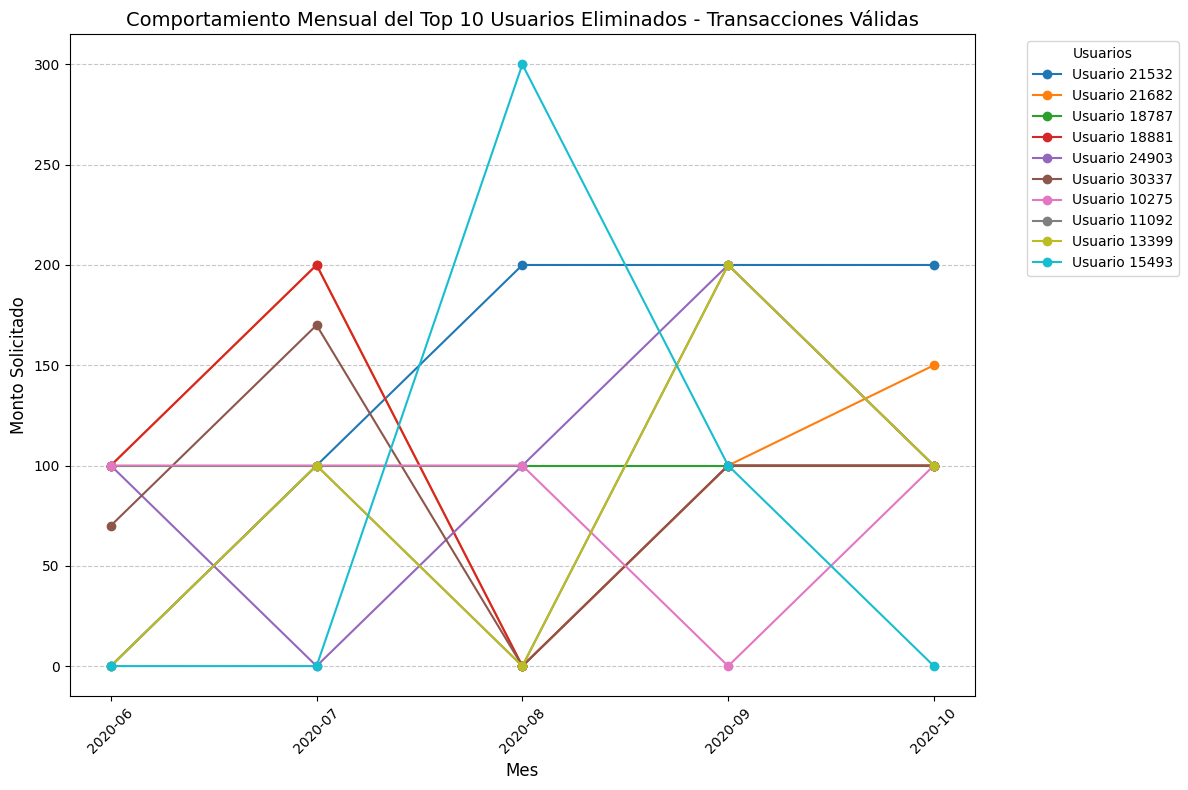

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear un rango completo de meses desde el primer hasta el último mes en los datos
all_months = pd.period_range(top_10_monthly['Mes'].min(), top_10_monthly['Mes'].max(), freq='M')

# Reindexar para incluir todos los meses y rellenar valores faltantes con 0
top_10_monthly_complete = top_10_monthly.set_index(['deleted_account_id', 'Mes']).unstack(fill_value=0).stack().reset_index()

# Crear el gráfico de líneas para el comportamiento mensual del Top 10
plt.figure(figsize=(12, 8))
for user_id in top_10_valid_eliminados['deleted_account_id']:
    user_data = top_10_monthly_complete[top_10_monthly_complete['deleted_account_id'] == user_id]
    plt.plot(user_data['Mes'].astype(str), user_data['amount'], marker='o', linestyle='-', label=f'Usuario {user_id}')

plt.title('Comportamiento Mensual del Top 10 Usuarios Eliminados - Transacciones Válidas', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Monto Solicitado', fontsize=12)
plt.xticks(all_months.astype(str), rotation=45)  # Mostrar todos los meses en el eje X
plt.legend(title="Usuarios", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


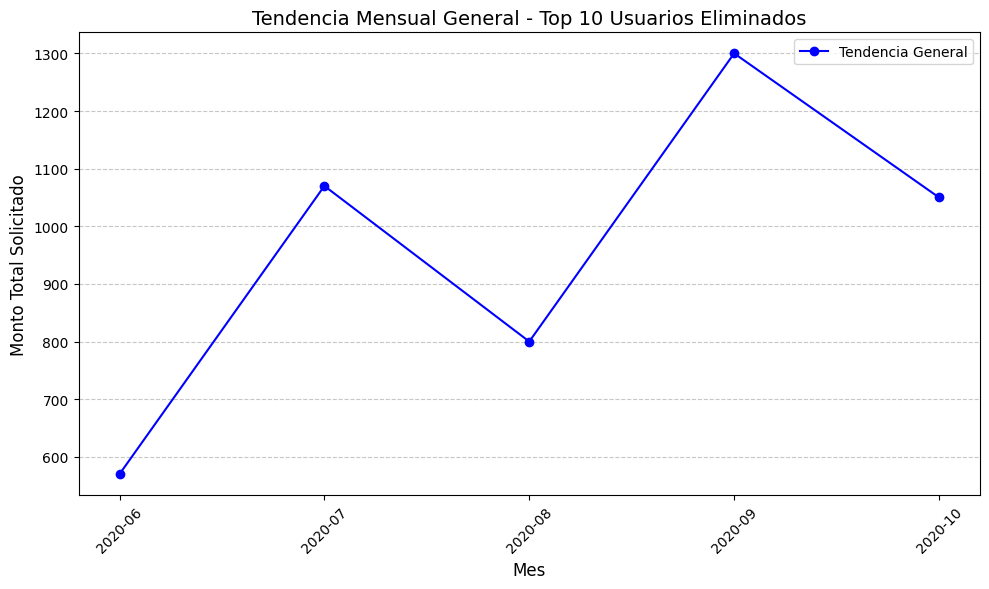

In [19]:
# Calcular la suma total de los montos solicitados por todos los usuarios del Top 10 para cada mes
total_monthly_trend = top_10_monthly.groupby('Mes')['amount'].sum().reset_index()

# Crear el gráfico de línea de tendencia general
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(total_monthly_trend['Mes'].astype(str), total_monthly_trend['amount'], marker='o', linestyle='-', color='blue', label='Tendencia General')
plt.title('Tendencia Mensual General - Top 10 Usuarios Eliminados', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Monto Total Solicitado', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


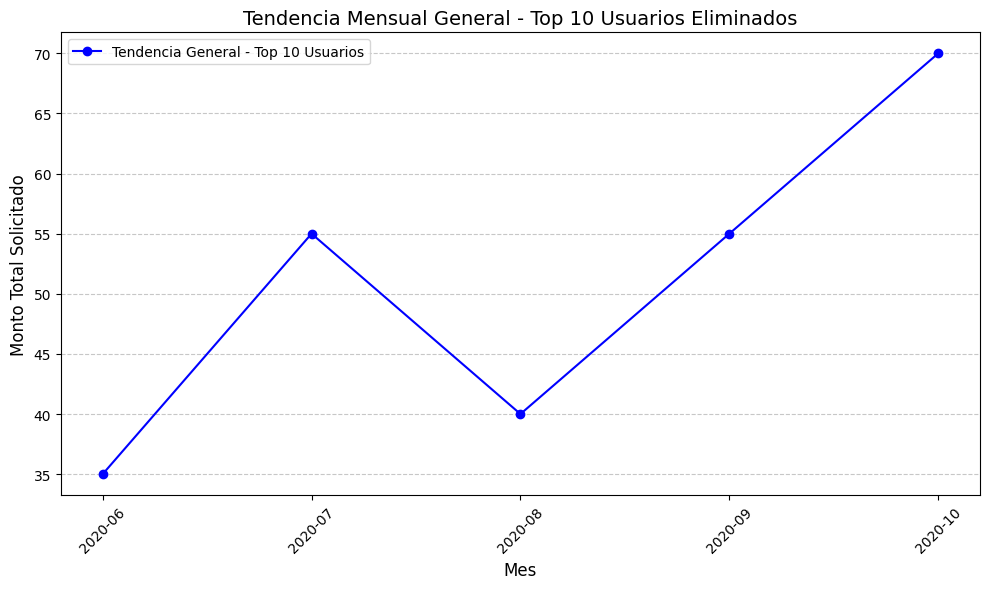

In [27]:
def plot_trend_for_top_users(top_n, transactions, group_column='deleted_account_id', time_column='Mes', amount_column='amount'):
    """
    Función para graficar la línea de tendencia del monto total solicitado por el Top N usuarios
    a lo largo del tiempo.

    Args:
    - top_n (int): Número de usuarios principales a considerar.
    - transactions (DataFrame): Dataset con transacciones válidas.
    - group_column (str): Columna de ID del usuario.
    - time_column (str): Columna de tiempo (Mes).
    - amount_column (str): Columna de monto solicitado.
    """
    # Calcular el Top N usuarios con mayores montos solicitados
    top_users = transactions.groupby(group_column).agg(total_amount_requested=(amount_column, 'sum')).nlargest(top_n, 'total_amount_requested').index

    # Filtrar transacciones del Top N usuarios
    top_transactions = transactions[transactions[group_column].isin(top_users)]

    # Agrupar por mes y sumar los montos solicitados
    total_monthly_trend = top_transactions.groupby(time_column)[amount_column].sum().reset_index()

    # Graficar la tendencia general
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(
        total_monthly_trend[time_column].astype(str),
        total_monthly_trend[amount_column],
        marker='o',
        linestyle='-',
        color='blue',
        label=f'Tendencia General - Top {top_n} Usuarios'
    )
    plt.title(f'Tendencia Mensual General - Top {top_n} Usuarios Eliminados', fontsize=14)
    plt.xlabel('Mes', fontsize=12)
    plt.ylabel('Monto Total Solicitado', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Filtrar solo transacciones válidas (status = 'accepted') en usuarios eliminados
valid_transactions_eliminados = usuarios_eliminados[usuarios_eliminados['status'] == 'accepted']

# Llamar a la función para graficar el Top 10
plot_trend_for_top_users(
    top_n=10,
    transactions=valid_transactions_eliminados,
    group_column='deleted_account_id',
    time_column='Mes',
    amount_column='total_amount'
)
